In [2]:
import numpy as np
import sys
from pathlib import Path
import torch
sys.path.insert(0, str(Path(".").resolve().parent.parent))

from src.evaluation.utils import load_model_from_checkpoint, maybe_build_dataloader_from_ckpt
from src.evaluation.checkpoint_eval import load_ckpt_artifacts

In [3]:
ckpt_path = "/myhome/iris/lightning_logs/cnet_experiment_polygon_projection-20251123-205745/cnet_cell_cycle/ry7evfji/checkpoints/epoch149-val_loss0.0198.ckpt"

In [4]:
# Auto-detect device
device = "cuda" if torch.cuda.is_available() else "cpu"

model, loader, projector = load_ckpt_artifacts(ckpt_path, device=device)

Loading checkpoint from: /myhome/iris/lightning_logs/cnet_experiment_polygon_projection-20251123-205745/cnet_cell_cycle/ry7evfji/checkpoints/epoch149-val_loss0.0198.ckpt

Setting up ModularCellDataModule

Creating image transform pipeline
   - Using [{'class_path': 'src.data_pipeline.data_transforms.SelectPlanesTransform', 'init_args': {'plane_selection': 'middle'}}, {'class_path': 'src.data_pipeline.data_transforms.NormalizeTransform', 'init_args': {'method': 'standardize', 'channel_keys': ['bf', '405']}}, {'class_path': 'src.data_pipeline.data_transforms.RemoveBackgroundTransform', 'init_args': {}}] transforms

Creating data source from: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg.h5
   ✓ Found 22,677 total cells

Applying quality filters:
   - Plane count: 3
   - Max objects: 1
   - Min segmentation pixels: 10
   - Max nuclei outside ratio: 0.2
✓ Loaded filter results from cache: /myhome/iris/data/fucci_3t3_221124_filtered_noNG030JP208_with_nuclei_seg_fi

In [28]:
from copy import deepcopy
from src.data_pipeline.data_transforms import RemoveBackgroundTransform

loader_raw = deepcopy(loader)
loader_raw.dataset.dataset.image_transform.transforms = [image_transform for image_transform in loader_raw.dataset.dataset.image_transform.transforms if not isinstance(image_transform, RemoveBackgroundTransform)]
loader_raw.dataset.dataset.image_transform.transforms

In [34]:
from copy import deepcopy
from tqdm import tqdm
from src.data_pipeline.data_transforms import RemoveBackgroundTransform

loader_iter = iter(loader)
loader_raw = deepcopy(loader)
loader_raw.dataset.dataset.image_transform.transforms = [
    image_transform
    for image_transform in loader_raw.dataset.dataset.image_transform.transforms
    if not isinstance(image_transform, RemoveBackgroundTransform)
]
loader_raw.dataset.dataset.image_transform.transforms
loader_raw_iter = iter(loader_raw)
predictions = []
targets = []
inputs = []
inputs_raw = []
for _ in tqdm(range(10), desc="Loading batches"):  # Get one batch
    batch = next(loader_iter)
    batch_raw = next(loader_raw_iter)
    x_raw, _ = batch_raw
    inputs_raw.extend(x_raw.cpu().tolist())
    x, y = batch
    with torch.no_grad():
        preds = model(x.to(device))
    targets.extend(y.cpu().tolist())
    inputs.extend(x.cpu().tolist())
    predictions.extend(preds.cpu().tolist())

Loading batches: 100%|██████████| 10/10 [01:47<00:00, 10.75s/it]


In [32]:
projector = loader.dataset.dataset.projector

if projector is not None:
    print("Projector type:", type(projector))
else:
    print("No projector found.")

residuals = np.asarray([projector.geodesic_distance(y_hat[0], y_true[0]) for y_hat, y_true in zip(predictions, targets)]) 

evaluation_tuples = list(zip(inputs_raw, inputs, targets, predictions, residuals))
evaluation_tuples = sorted(evaluation_tuples, key=lambda t: np.abs(t[4]), reverse=True)

Projector type: <class 'src.data_pipeline.curve_projector.FucciCurveProjector'>


Target sample: [0.20249709486961365]
Prediction sample: [0.6259282827377319]
Residual (geodesic distance): 0.4234311878681183
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


/myhome/iris/src/data_pipeline/curve_projector.py:549: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


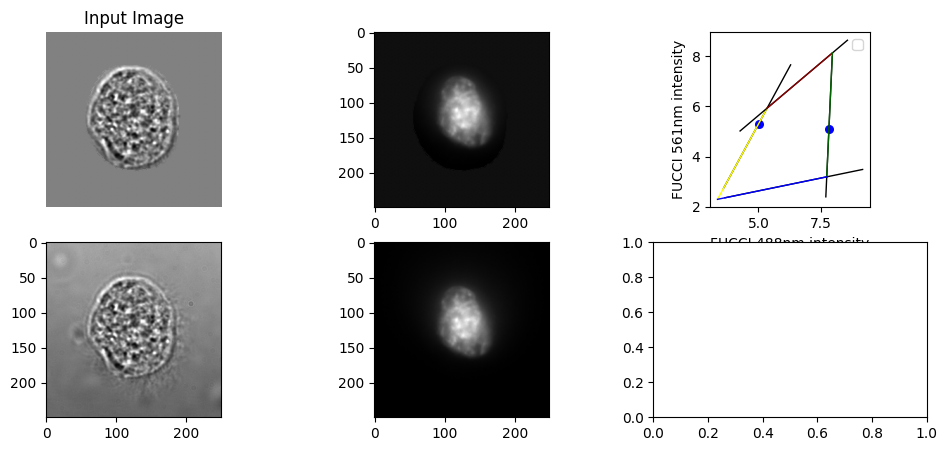

<Figure size 640x480 with 0 Axes>

Target sample: [0.793413519859314]
Prediction sample: [0.4441449046134949]
Residual (geodesic distance): -0.3492686152458191
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


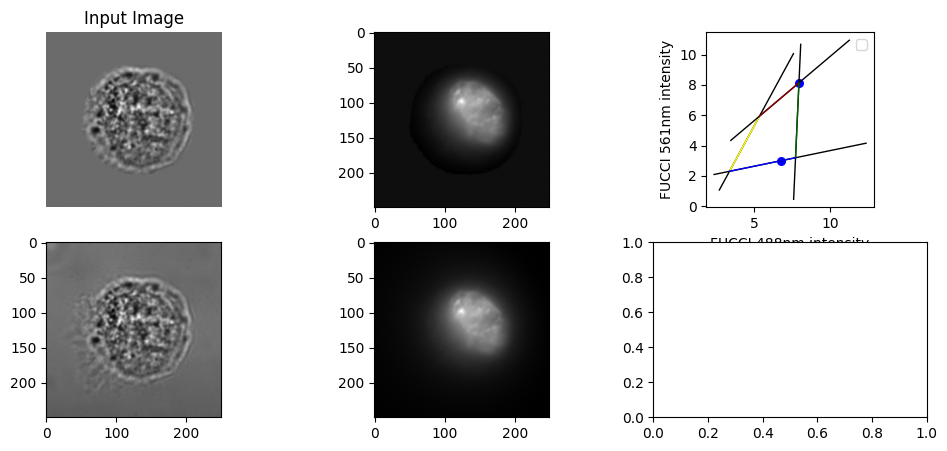

<Figure size 640x480 with 0 Axes>

Target sample: [0.7784921526908875]
Prediction sample: [0.47645139694213867]
Residual (geodesic distance): -0.3020407557487488
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


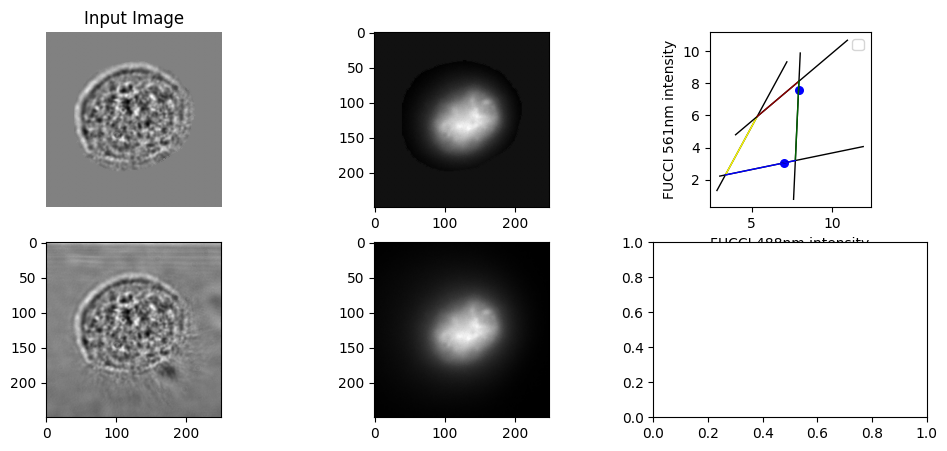

<Figure size 640x480 with 0 Axes>

Target sample: [0.747277557849884]
Prediction sample: [0.4660128653049469]
Residual (geodesic distance): -0.28126469254493713
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


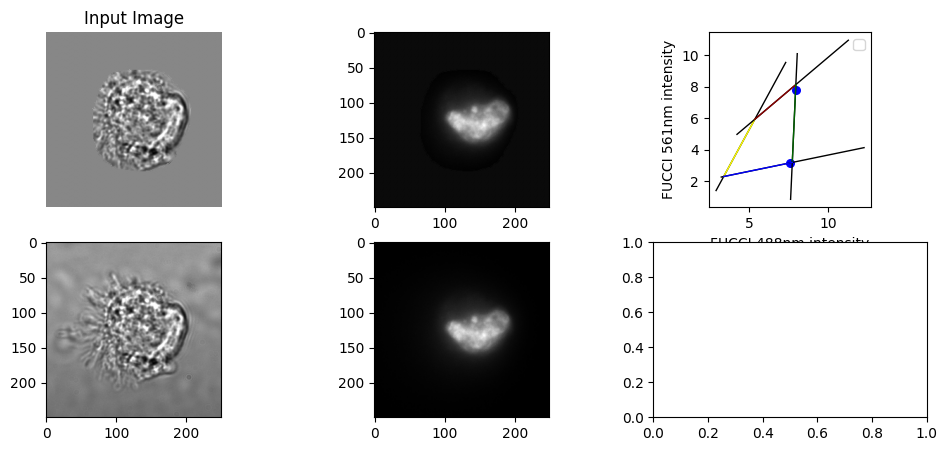

<Figure size 640x480 with 0 Axes>

Target sample: [0.33321046829223633]
Prediction sample: [0.5884244441986084]
Residual (geodesic distance): 0.25521397590637207
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


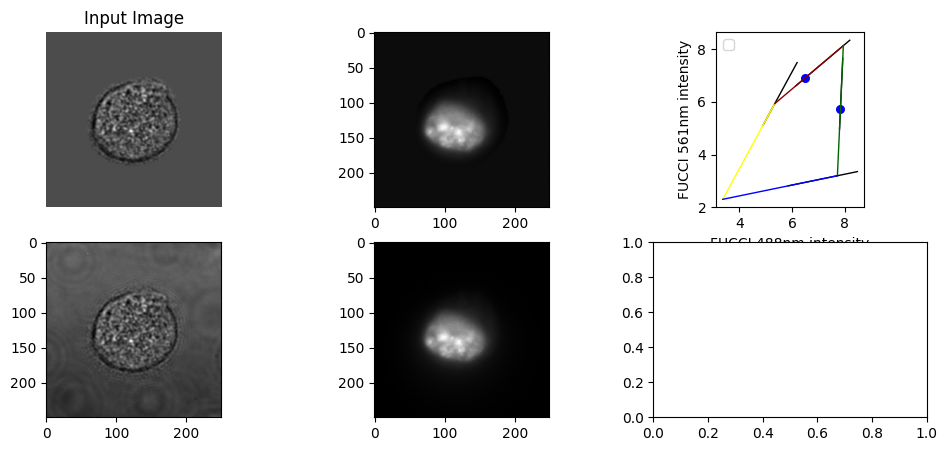

<Figure size 640x480 with 0 Axes>

Target sample: [0.7375377416610718]
Prediction sample: [0.49050405621528625]
Residual (geodesic distance): -0.24703368544578552
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


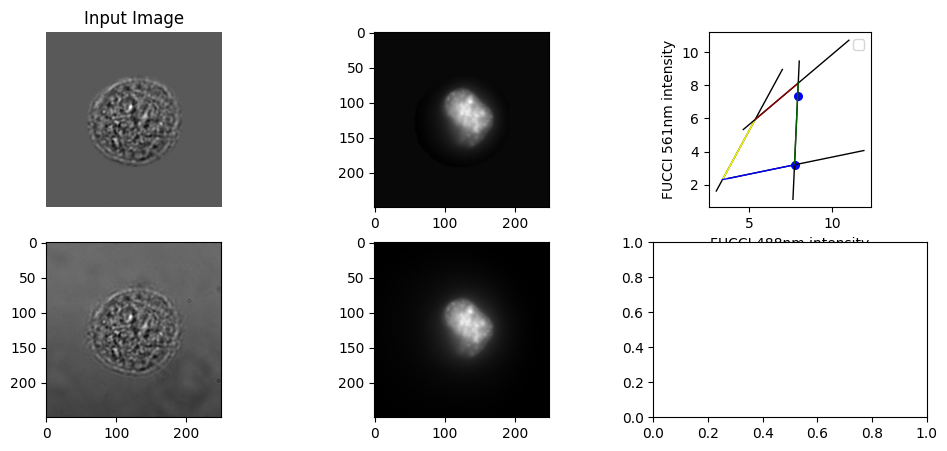

<Figure size 640x480 with 0 Axes>

Target sample: [0.15681152045726776]
Prediction sample: [0.39606916904449463]
Residual (geodesic distance): 0.23925764858722687
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


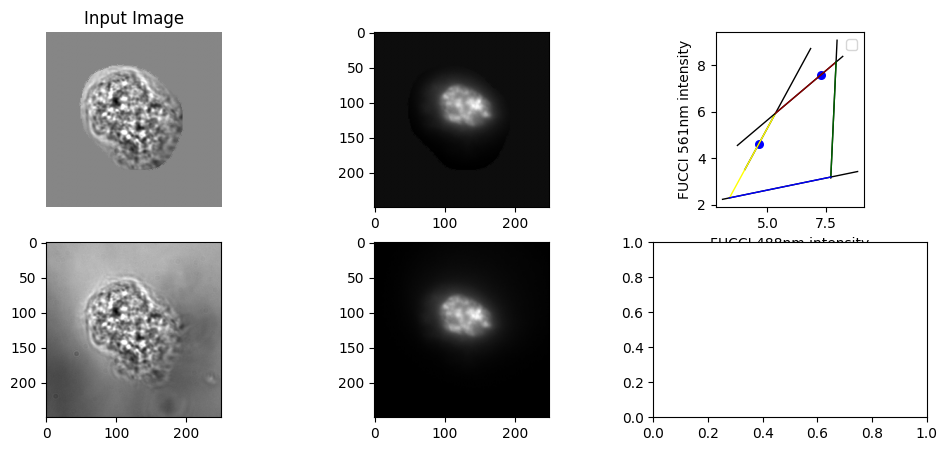

<Figure size 640x480 with 0 Axes>

Target sample: [0.7599475383758545]
Prediction sample: [0.5391494631767273]
Residual (geodesic distance): -0.2207980751991272
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


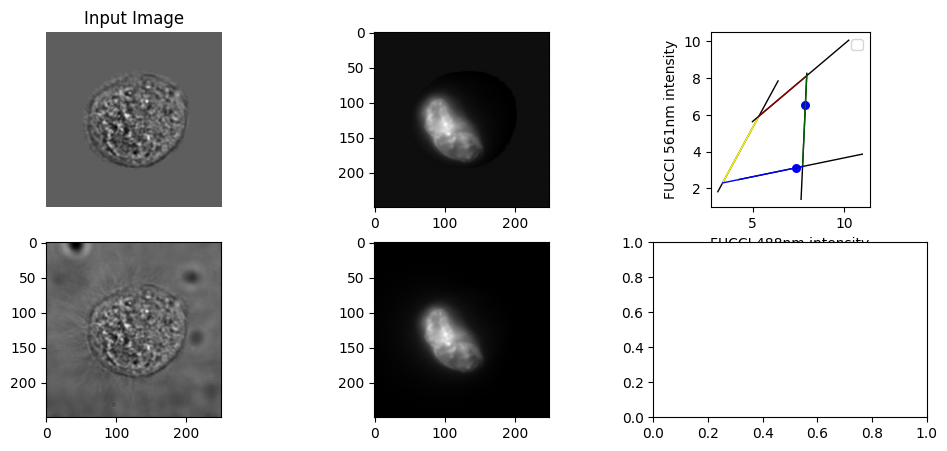

<Figure size 640x480 with 0 Axes>

Target sample: [0.38975226879119873]
Prediction sample: [0.60191410779953]
Residual (geodesic distance): 0.2121618390083313
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


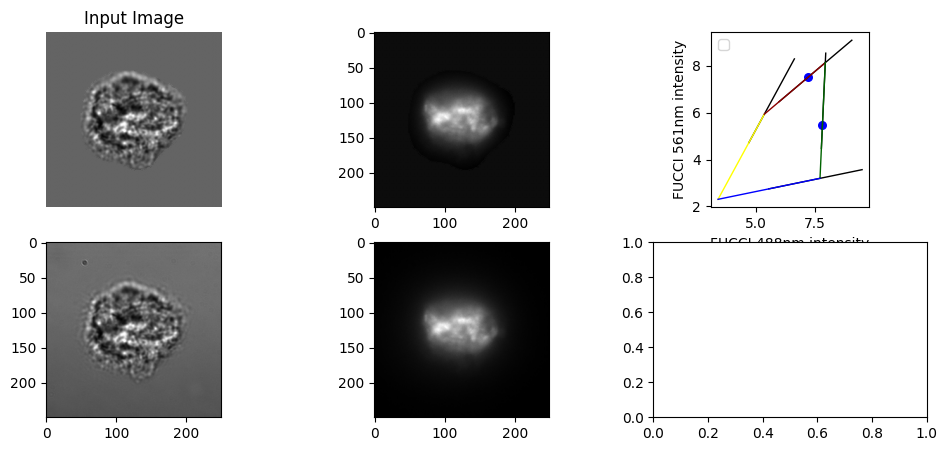

<Figure size 640x480 with 0 Axes>

Target sample: [0.2885386645793915]
Prediction sample: [0.47869330644607544]
Residual (geodesic distance): 0.19015464186668396
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


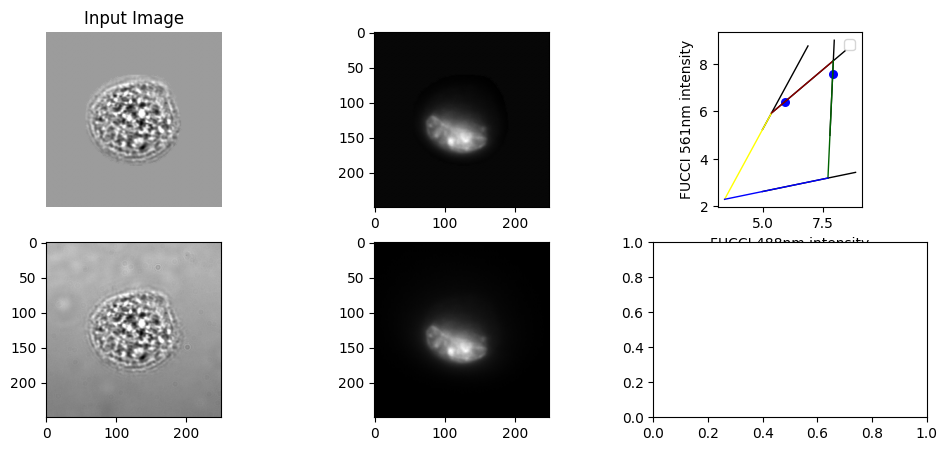

<Figure size 640x480 with 0 Axes>

Target sample: [0.7619659900665283]
Prediction sample: [0.5810356736183167]
Residual (geodesic distance): -0.18093031644821167
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


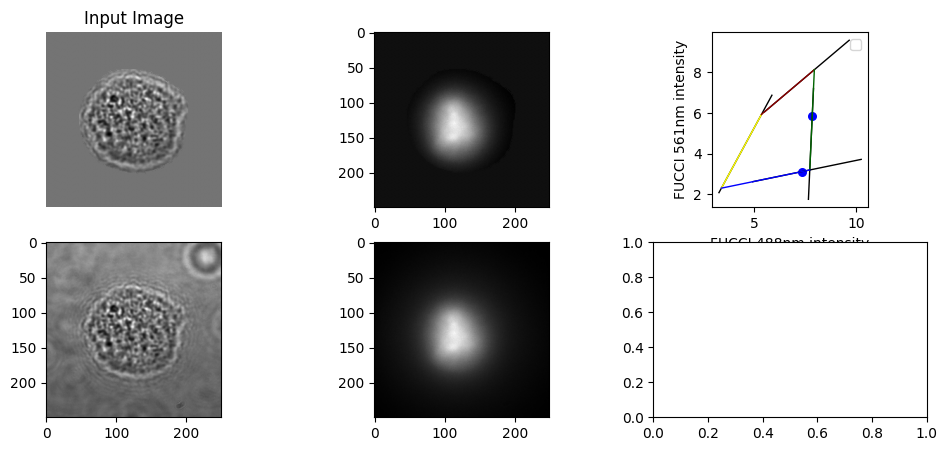

<Figure size 640x480 with 0 Axes>

Target sample: [0.16989442706108093]
Prediction sample: [0.3474790155887604]
Residual (geodesic distance): 0.17758458852767944
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


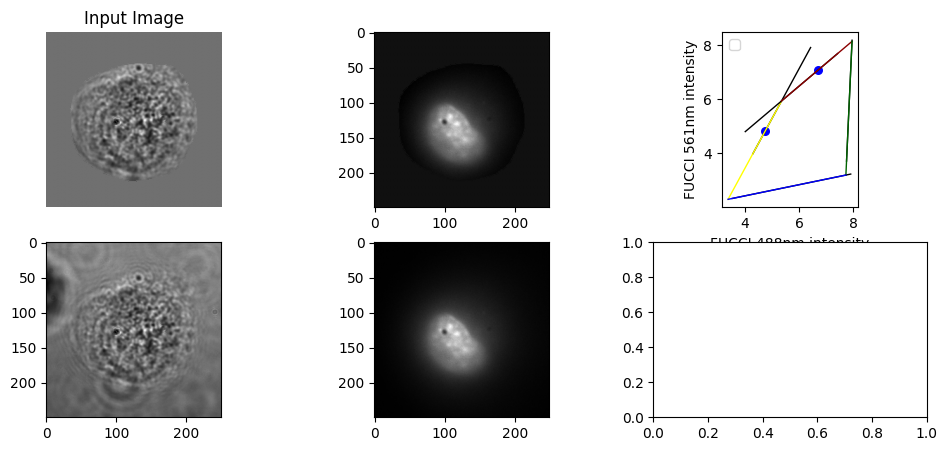

<Figure size 640x480 with 0 Axes>

Target sample: [0.3437259793281555]
Prediction sample: [0.17980632185935974]
Residual (geodesic distance): -0.16391965746879578
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


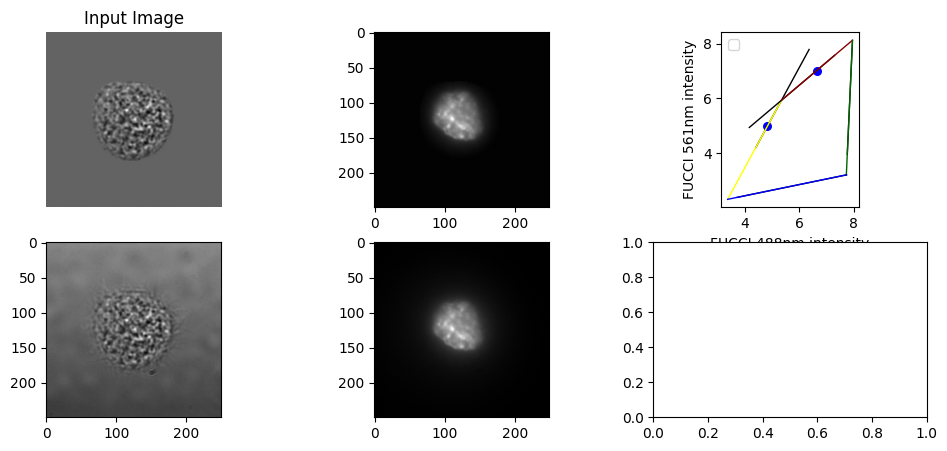

<Figure size 640x480 with 0 Axes>

Target sample: [0.29590049386024475]
Prediction sample: [0.4492572247982025]
Residual (geodesic distance): 0.15335673093795776
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


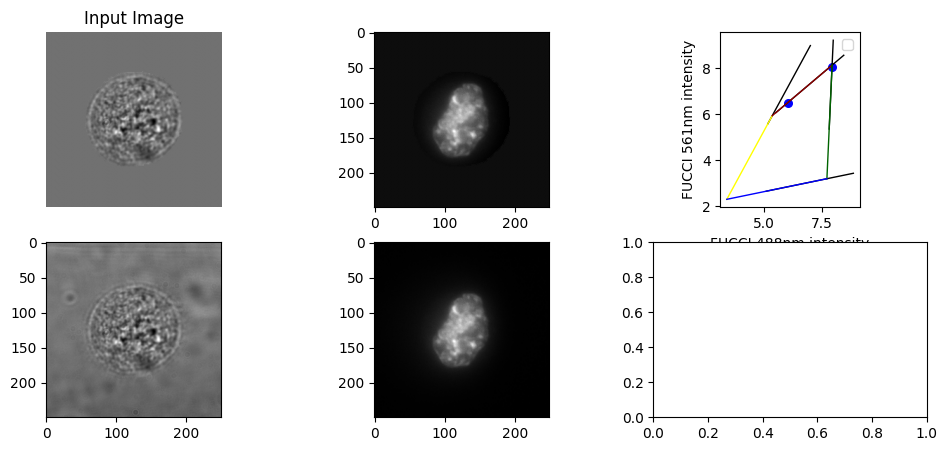

<Figure size 640x480 with 0 Axes>

Target sample: [0.03511665016412735]
Prediction sample: [0.17319391667842865]
Residual (geodesic distance): 0.1380772665143013
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


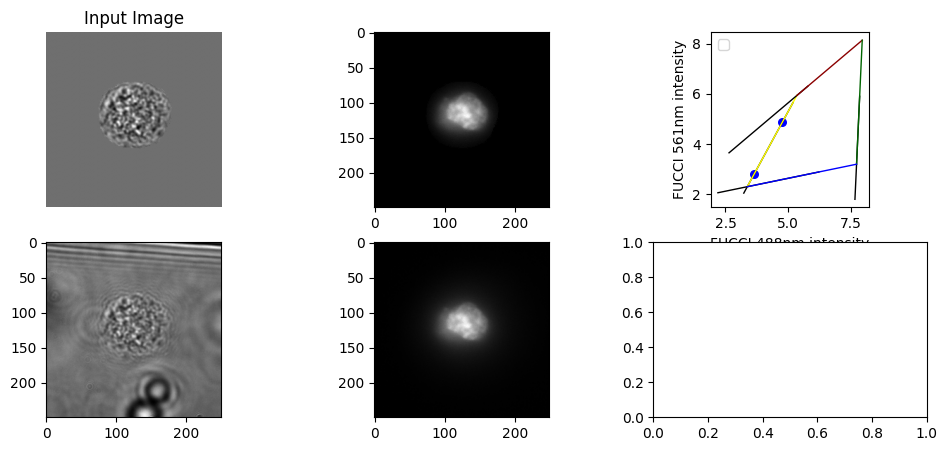

<Figure size 640x480 with 0 Axes>

Target sample: [0.7392597794532776]
Prediction sample: [0.6044682264328003]
Residual (geodesic distance): -0.1347915530204773
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


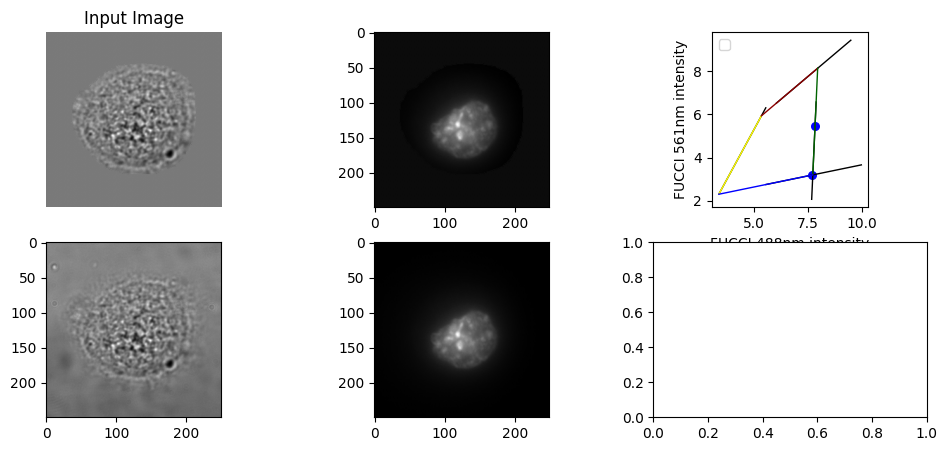

<Figure size 640x480 with 0 Axes>

Target sample: [0.3054828345775604]
Prediction sample: [0.43695661425590515]
Residual (geodesic distance): 0.13147377967834473
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


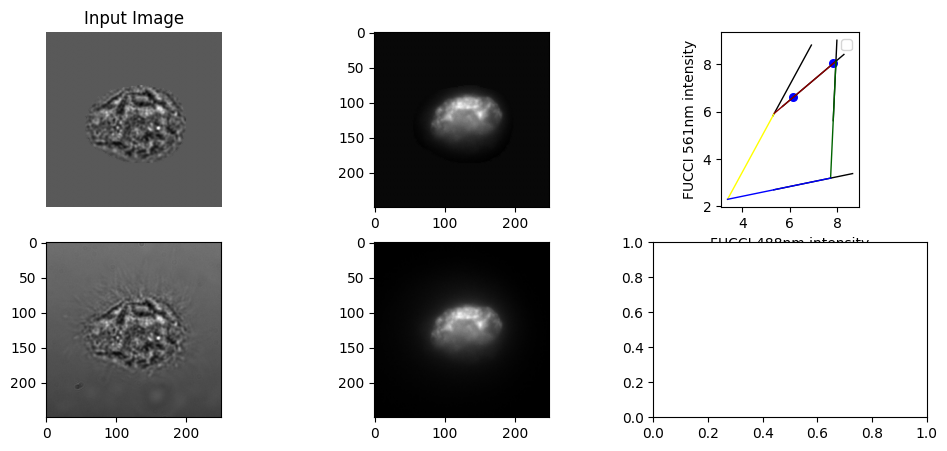

<Figure size 640x480 with 0 Axes>

Target sample: [0.3841201663017273]
Prediction sample: [0.25390344858169556]
Residual (geodesic distance): -0.13021671772003174
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


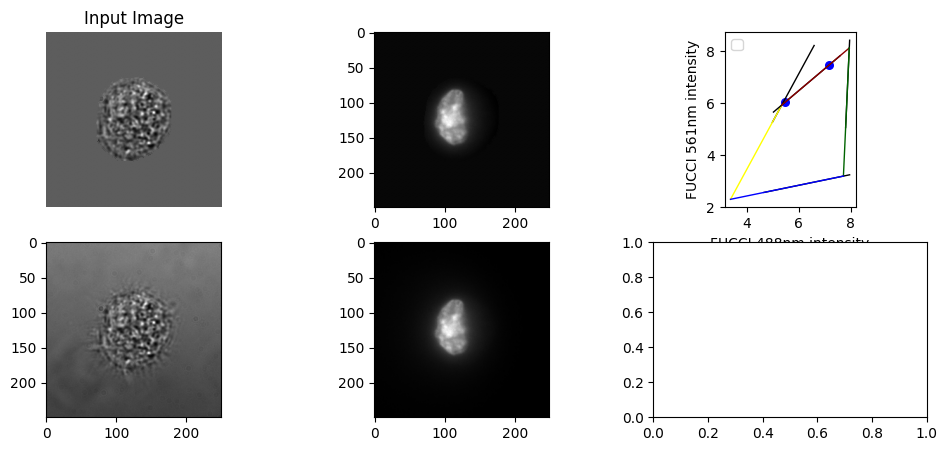

<Figure size 640x480 with 0 Axes>

Target sample: [0.15232311189174652]
Prediction sample: [0.2779494524002075]
Residual (geodesic distance): 0.125626340508461
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


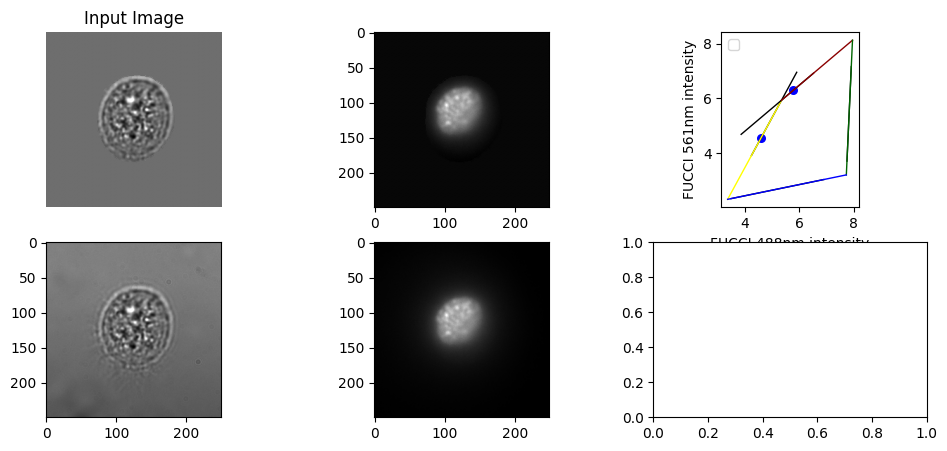

<Figure size 640x480 with 0 Axes>

Target sample: [0.20746716856956482]
Prediction sample: [0.3330654203891754]
Residual (geodesic distance): 0.1255982518196106
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


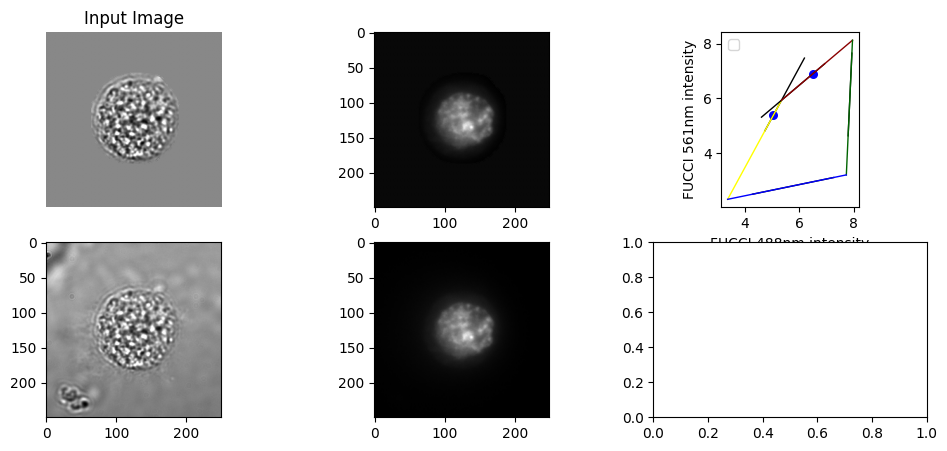

<Figure size 640x480 with 0 Axes>

Target sample: [0.711033046245575]
Prediction sample: [0.5922913551330566]
Residual (geodesic distance): -0.11874169111251831
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


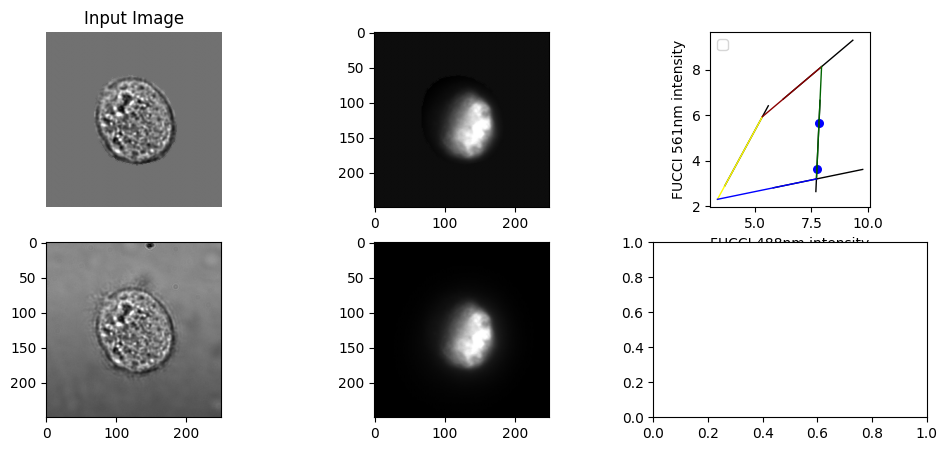

<Figure size 640x480 with 0 Axes>

Target sample: [0.6017409563064575]
Prediction sample: [0.48435571789741516]
Residual (geodesic distance): -0.11738523840904236
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


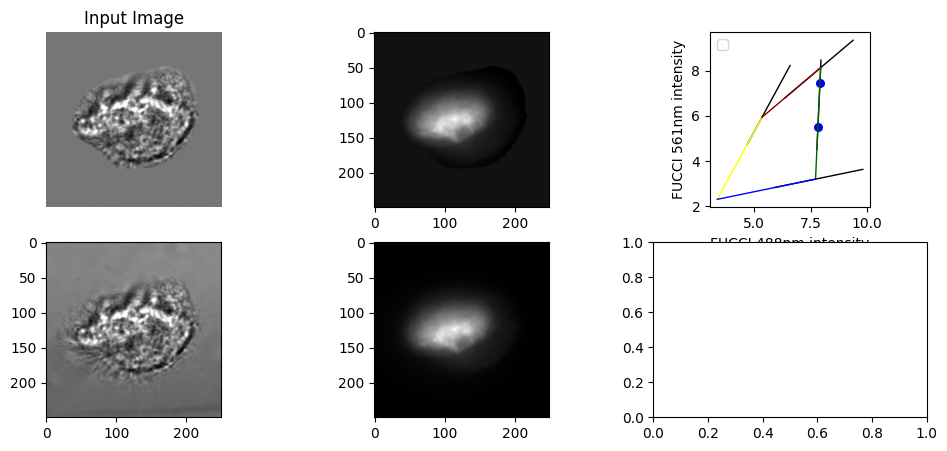

<Figure size 640x480 with 0 Axes>

Target sample: [0.31187930703163147]
Prediction sample: [0.42702510952949524]
Residual (geodesic distance): 0.11514580249786377
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


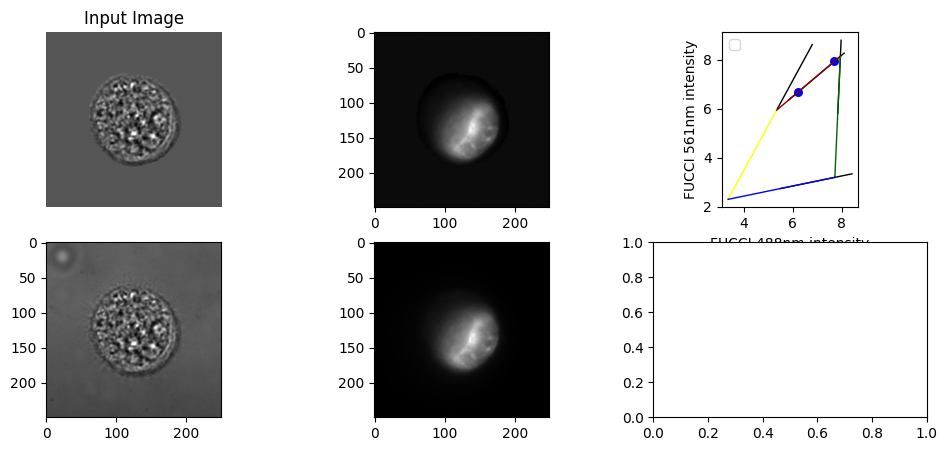

<Figure size 640x480 with 0 Axes>

Target sample: [0.6731444597244263]
Prediction sample: [0.5659061670303345]
Residual (geodesic distance): -0.1072382926940918
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


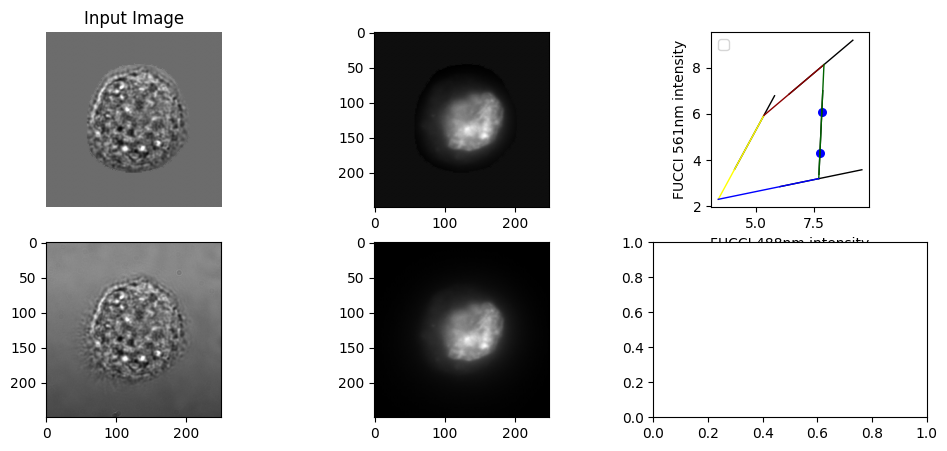

<Figure size 640x480 with 0 Axes>

Target sample: [0.13842278718948364]
Prediction sample: [0.24154260754585266]
Residual (geodesic distance): 0.10311982035636902
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


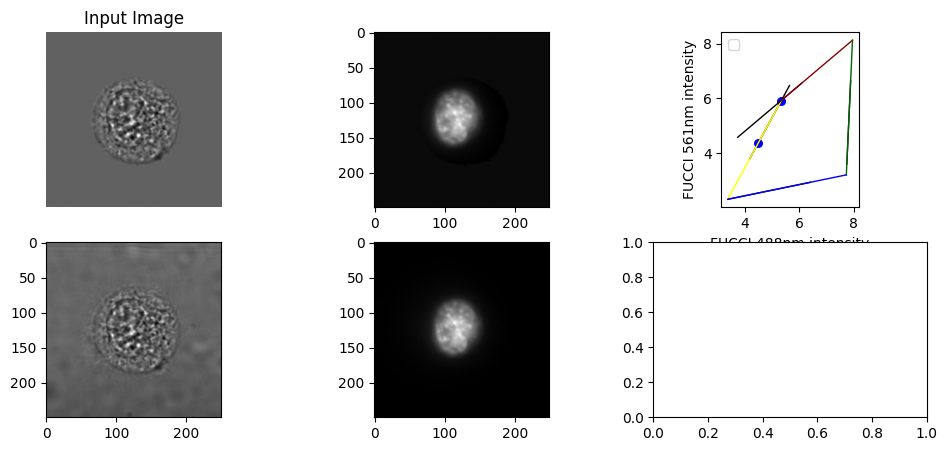

<Figure size 640x480 with 0 Axes>

Target sample: [0.3706415891647339]
Prediction sample: [0.2678355872631073]
Residual (geodesic distance): -0.10280600190162659
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


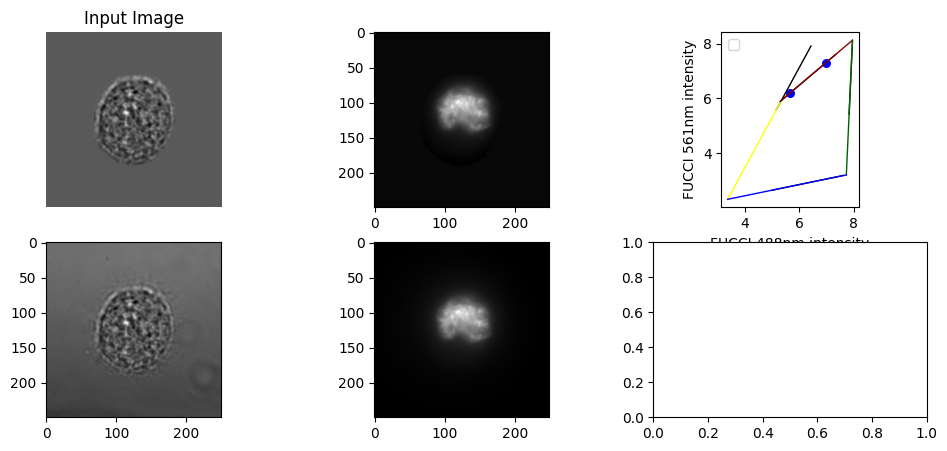

<Figure size 640x480 with 0 Axes>

Target sample: [0.1942339688539505]
Prediction sample: [0.29314133524894714]
Residual (geodesic distance): 0.09890736639499664
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


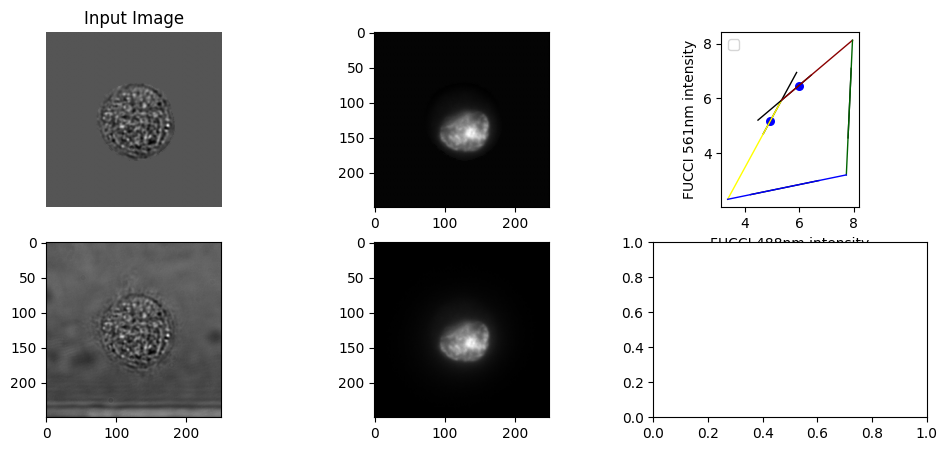

<Figure size 640x480 with 0 Axes>

Target sample: [0.22691719233989716]
Prediction sample: [0.3163347840309143]
Residual (geodesic distance): 0.08941759169101715
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


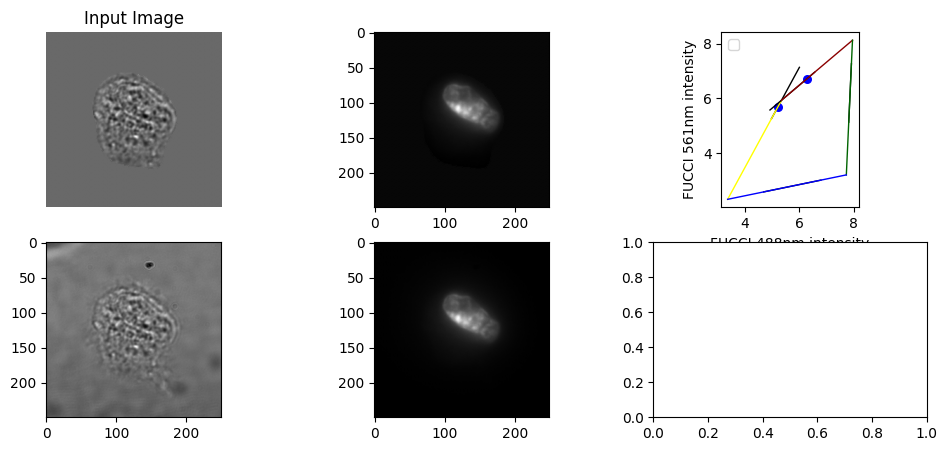

<Figure size 640x480 with 0 Axes>

Target sample: [0.6357712745666504]
Prediction sample: [0.547678530216217]
Residual (geodesic distance): -0.08809274435043335
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


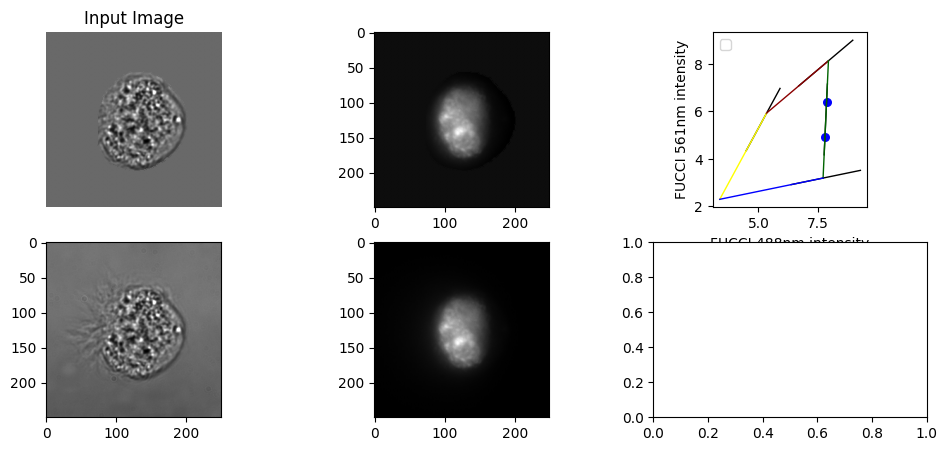

<Figure size 640x480 with 0 Axes>

Target sample: [0.33679014444351196]
Prediction sample: [0.42083168029785156]
Residual (geodesic distance): 0.0840415358543396
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


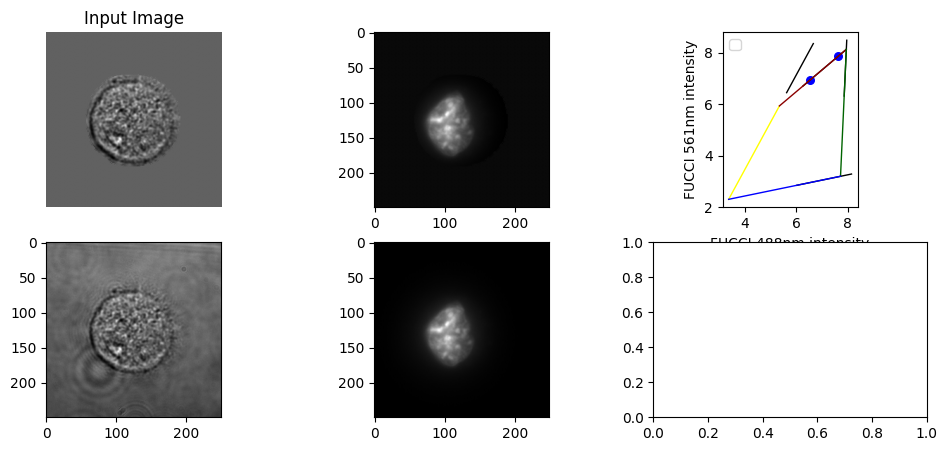

<Figure size 640x480 with 0 Axes>

Target sample: [0.13668307662010193]
Prediction sample: [0.2189173698425293]
Residual (geodesic distance): 0.08223429322242737
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


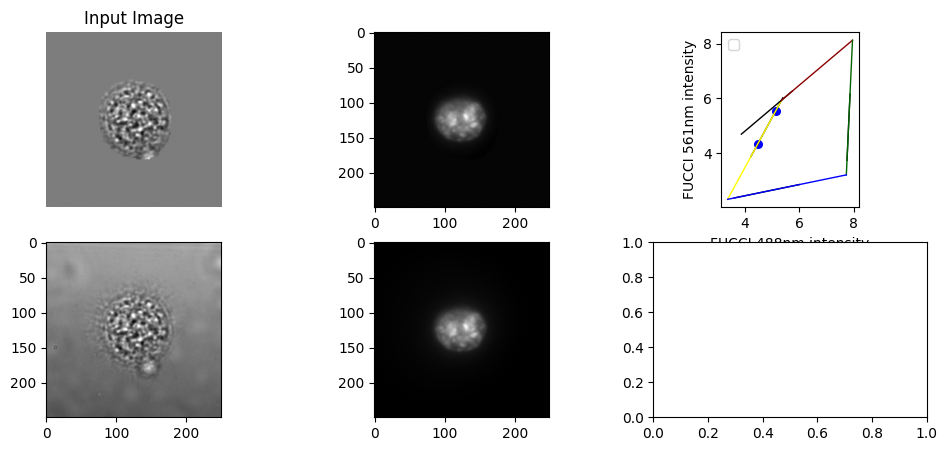

<Figure size 640x480 with 0 Axes>

Target sample: [0.2147531509399414]
Prediction sample: [0.2955707311630249]
Residual (geodesic distance): 0.0808175802230835
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


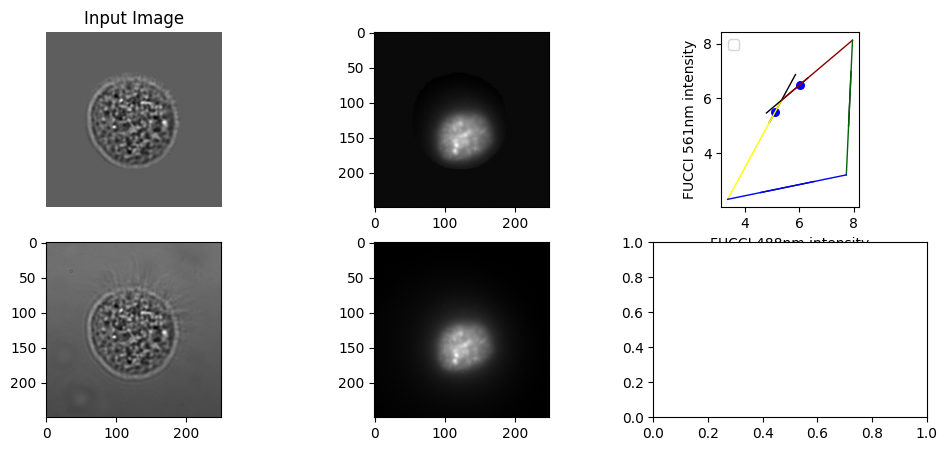

<Figure size 640x480 with 0 Axes>

Target sample: [0.3974282443523407]
Prediction sample: [0.32274186611175537]
Residual (geodesic distance): -0.07468637824058533
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


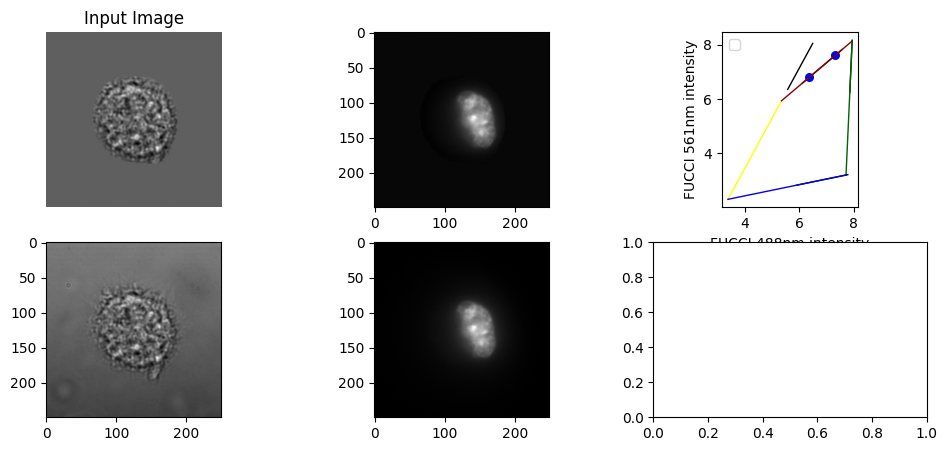

<Figure size 640x480 with 0 Axes>

Target sample: [0.2769060432910919]
Prediction sample: [0.3455963134765625]
Residual (geodesic distance): 0.06869027018547058
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


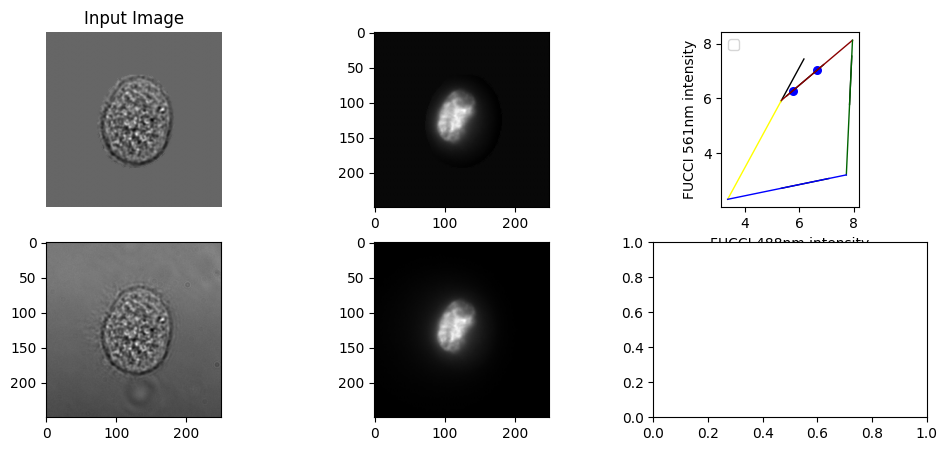

<Figure size 640x480 with 0 Axes>

Target sample: [0.47890928387641907]
Prediction sample: [0.546970546245575]
Residual (geodesic distance): 0.06806126236915588
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


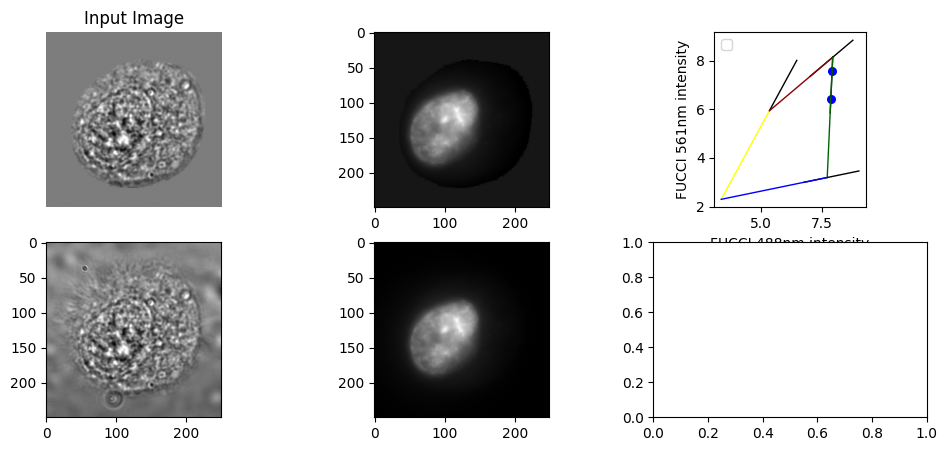

<Figure size 640x480 with 0 Axes>

Target sample: [0.7242274880409241]
Prediction sample: [0.6561840176582336]
Residual (geodesic distance): -0.06804347038269043
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


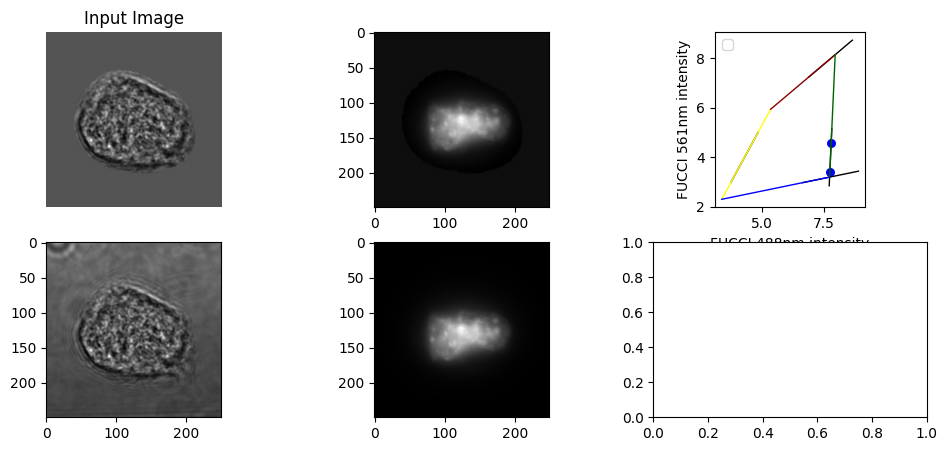

<Figure size 640x480 with 0 Axes>

Target sample: [0.28517982363700867]
Prediction sample: [0.2189916968345642]
Residual (geodesic distance): -0.06618812680244446
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


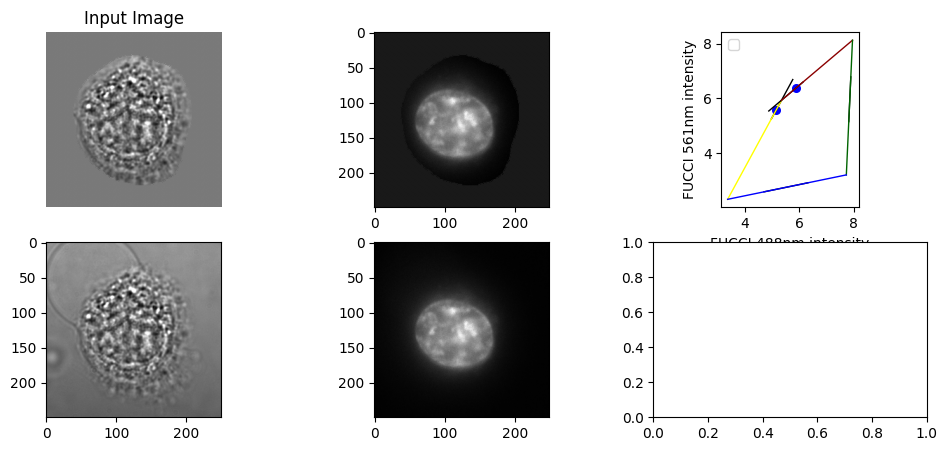

<Figure size 640x480 with 0 Axes>

Target sample: [0.7319990396499634]
Prediction sample: [0.6683696508407593]
Residual (geodesic distance): -0.0636293888092041
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


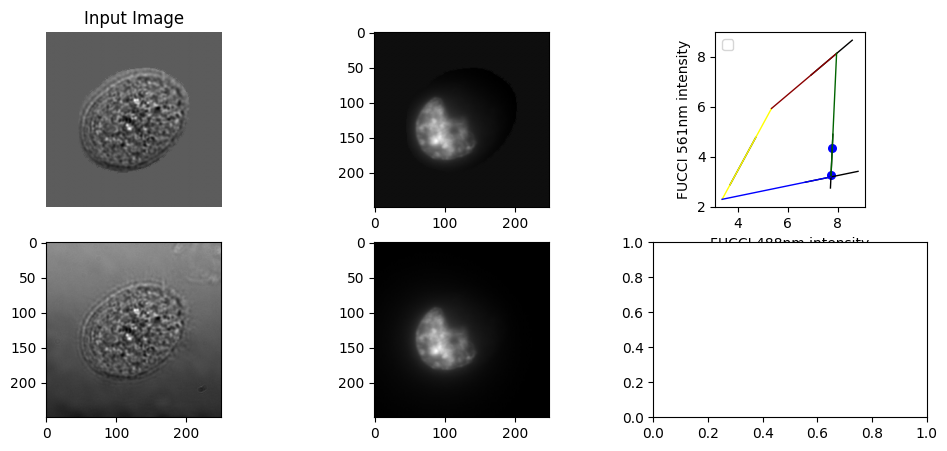

<Figure size 640x480 with 0 Axes>

Target sample: [0.3304583728313446]
Prediction sample: [0.2672303318977356]
Residual (geodesic distance): -0.06322804093360901
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


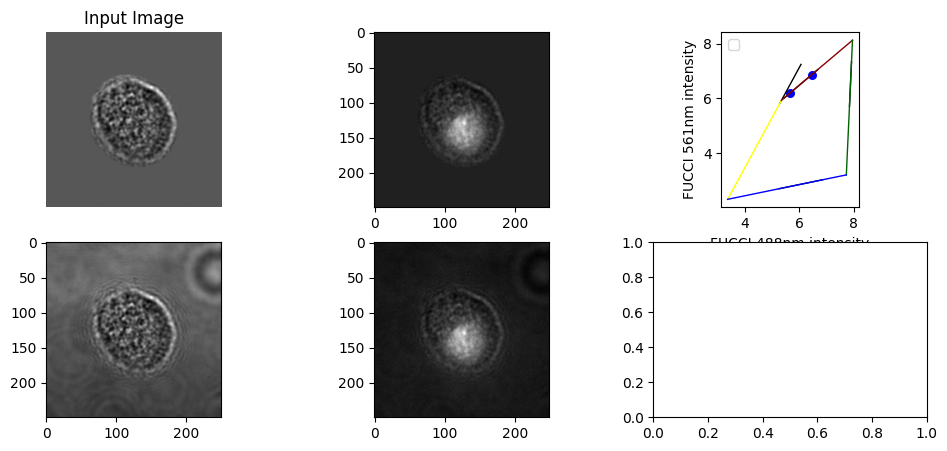

<Figure size 640x480 with 0 Axes>

Target sample: [0.2386743724346161]
Prediction sample: [0.2971278727054596]
Residual (geodesic distance): 0.058453500270843506
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


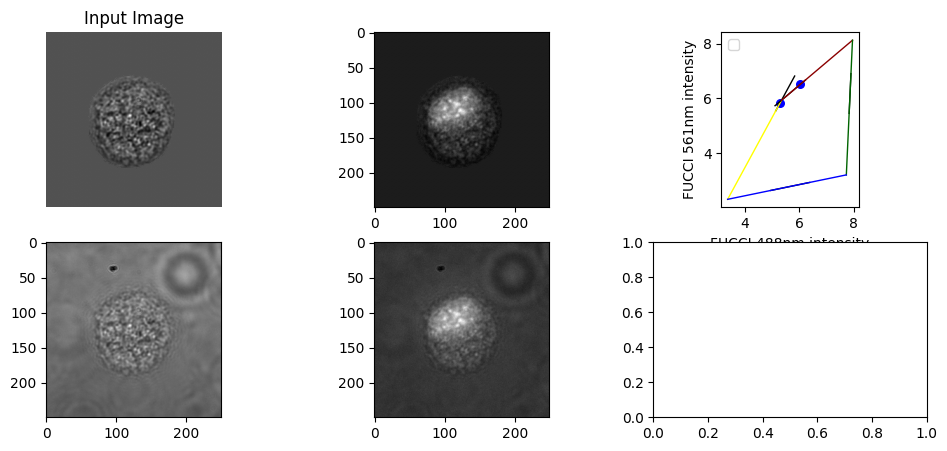

<Figure size 640x480 with 0 Axes>

Target sample: [0.3583206236362457]
Prediction sample: [0.4138020873069763]
Residual (geodesic distance): 0.05548146367073059
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


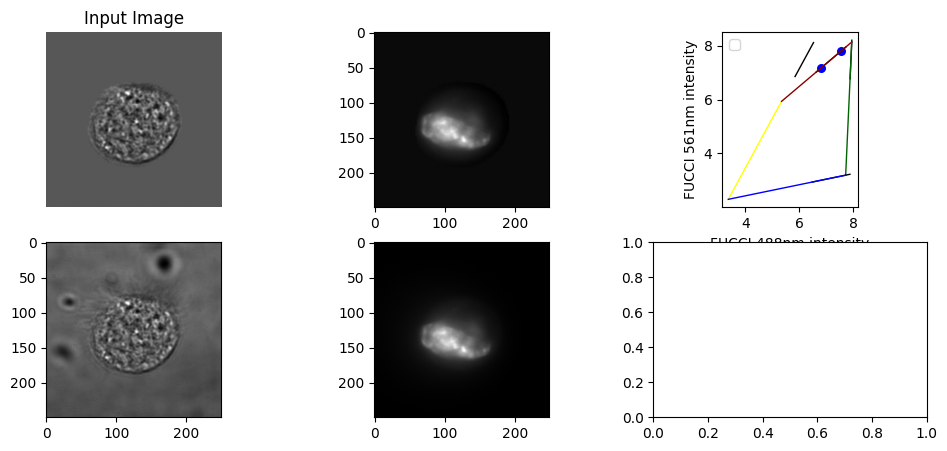

<Figure size 640x480 with 0 Axes>

Target sample: [0.20844663679599762]
Prediction sample: [0.2566184997558594]
Residual (geodesic distance): 0.048171862959861755
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


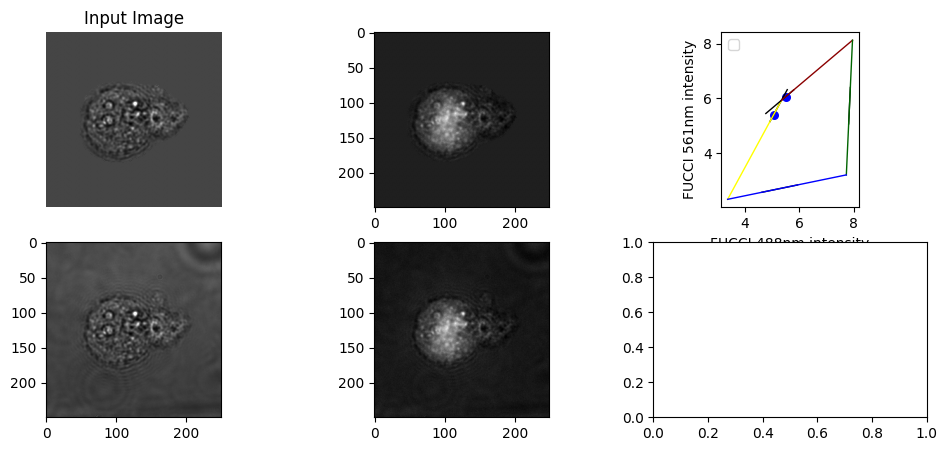

<Figure size 640x480 with 0 Axes>

Target sample: [0.30506181716918945]
Prediction sample: [0.2574484348297119]
Residual (geodesic distance): -0.04761338233947754
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


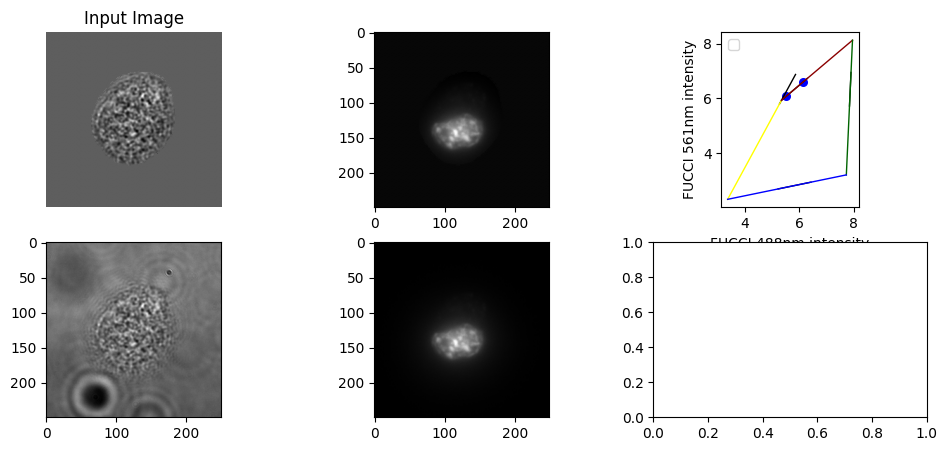

<Figure size 640x480 with 0 Axes>

Target sample: [0.1612391322851181]
Prediction sample: [0.2025575339794159]
Residual (geodesic distance): 0.04131840169429779
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


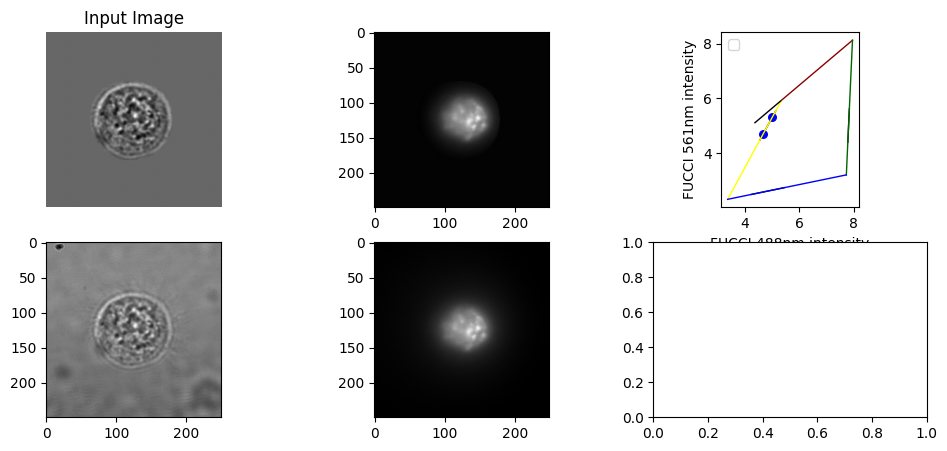

<Figure size 640x480 with 0 Axes>

Target sample: [0.7375377416610718]
Prediction sample: [0.700090229511261]
Residual (geodesic distance): -0.03744751214981079
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


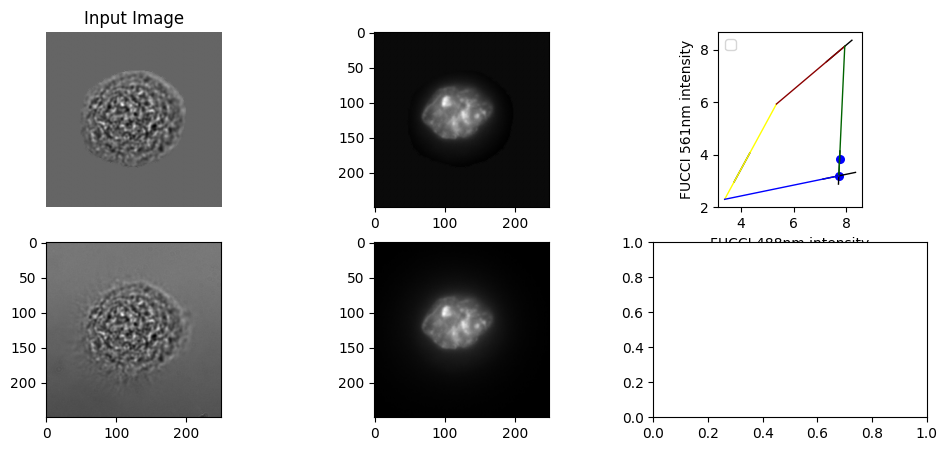

<Figure size 640x480 with 0 Axes>

Target sample: [0.3261386752128601]
Prediction sample: [0.361651211977005]
Residual (geodesic distance): 0.0355125367641449
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


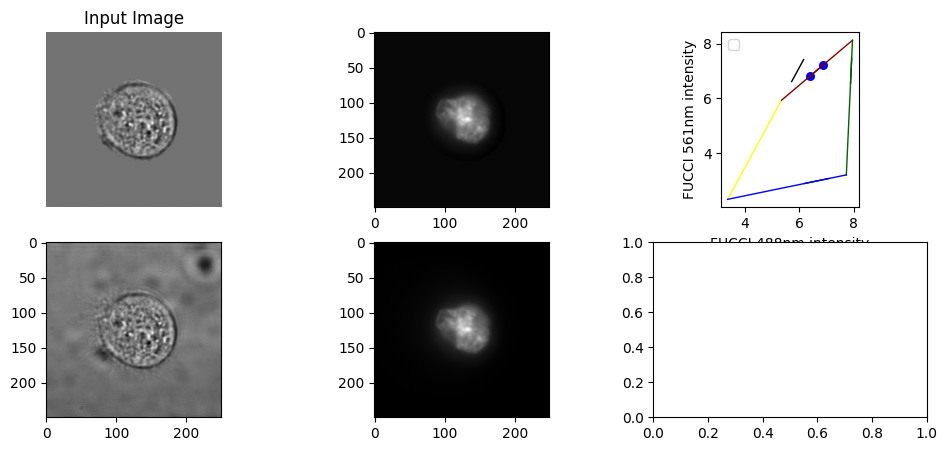

<Figure size 640x480 with 0 Axes>

Target sample: [0.425043523311615]
Prediction sample: [0.4533121883869171]
Residual (geodesic distance): 0.028268665075302124
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


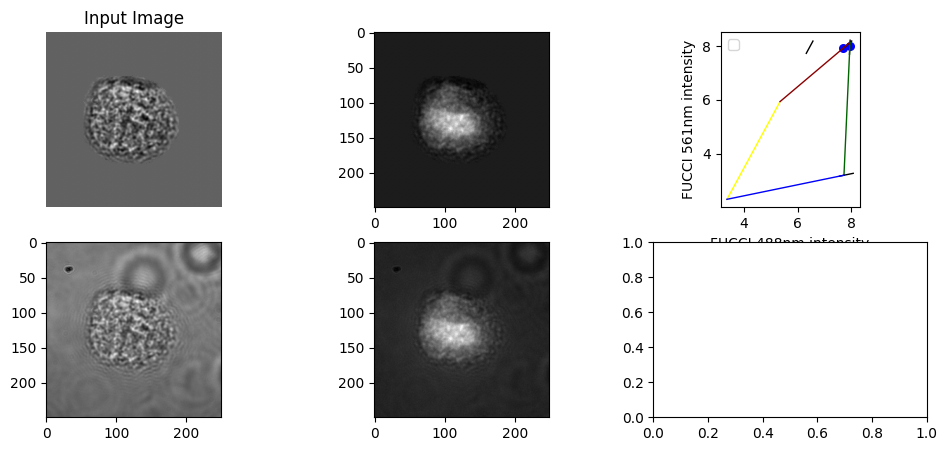

<Figure size 640x480 with 0 Axes>

Target sample: [0.1260916292667389]
Prediction sample: [0.15396429598331451]
Residual (geodesic distance): 0.027872666716575623
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


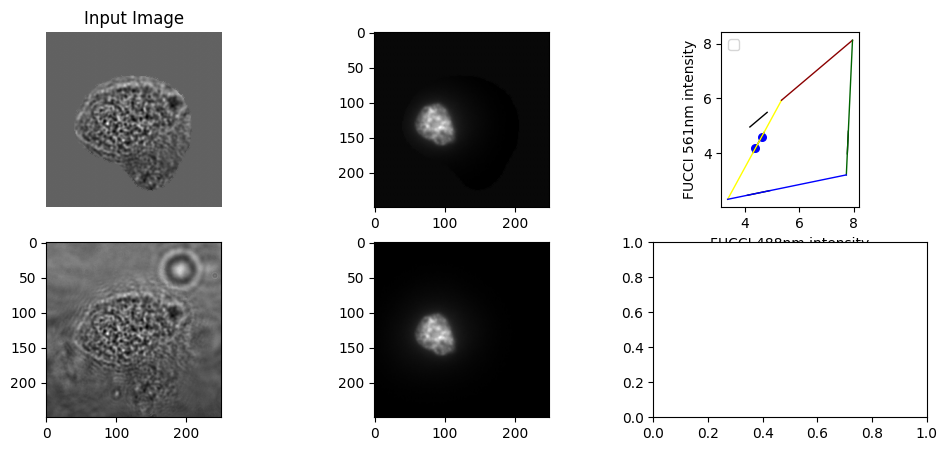

<Figure size 640x480 with 0 Axes>

Target sample: [0.14455288648605347]
Prediction sample: [0.17121079564094543]
Residual (geodesic distance): 0.026657909154891968
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


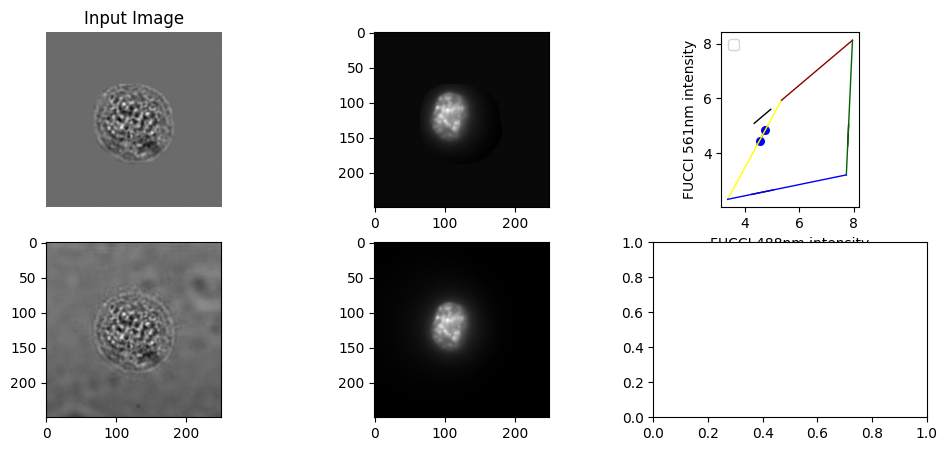

<Figure size 640x480 with 0 Axes>

Target sample: [0.34397074580192566]
Prediction sample: [0.36982741951942444]
Residual (geodesic distance): 0.02585667371749878
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


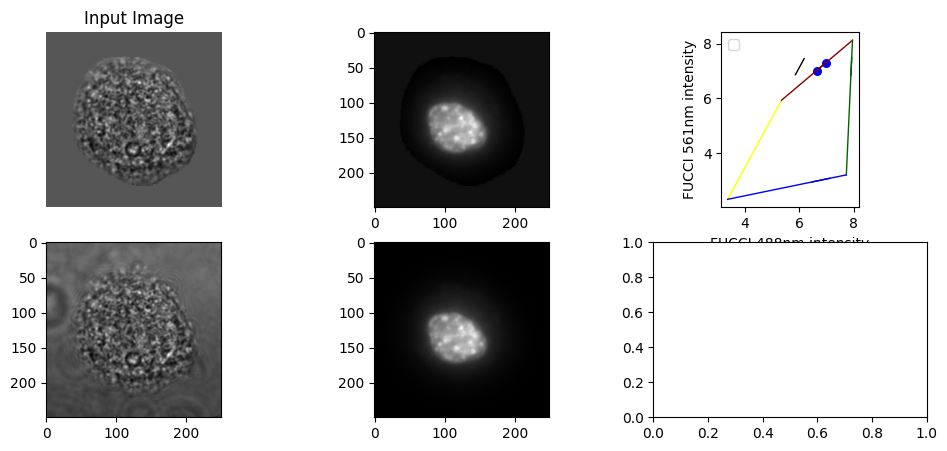

<Figure size 640x480 with 0 Axes>

Target sample: [0.28729626536369324]
Prediction sample: [0.31198424100875854]
Residual (geodesic distance): 0.024687975645065308
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


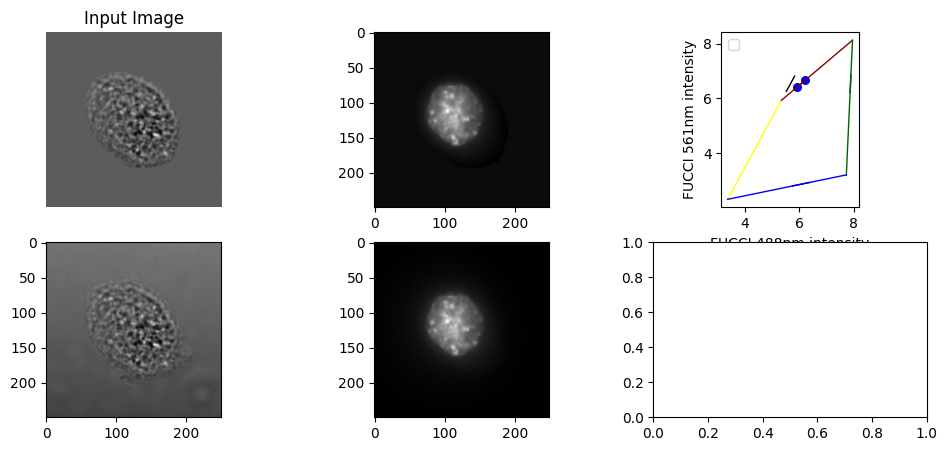

<Figure size 640x480 with 0 Axes>

Target sample: [0.293626606464386]
Prediction sample: [0.31774458289146423]
Residual (geodesic distance): 0.024117976427078247
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


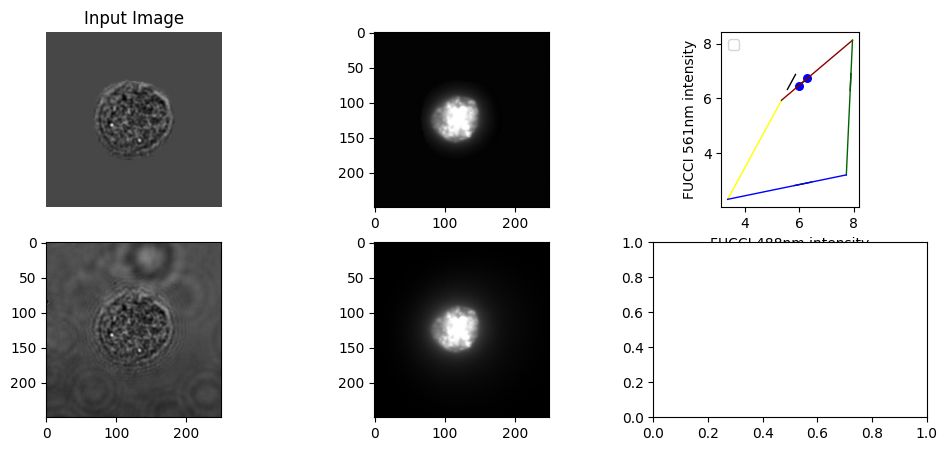

<Figure size 640x480 with 0 Axes>

Target sample: [0.4802502691745758]
Prediction sample: [0.503571629524231]
Residual (geodesic distance): 0.02332136034965515
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


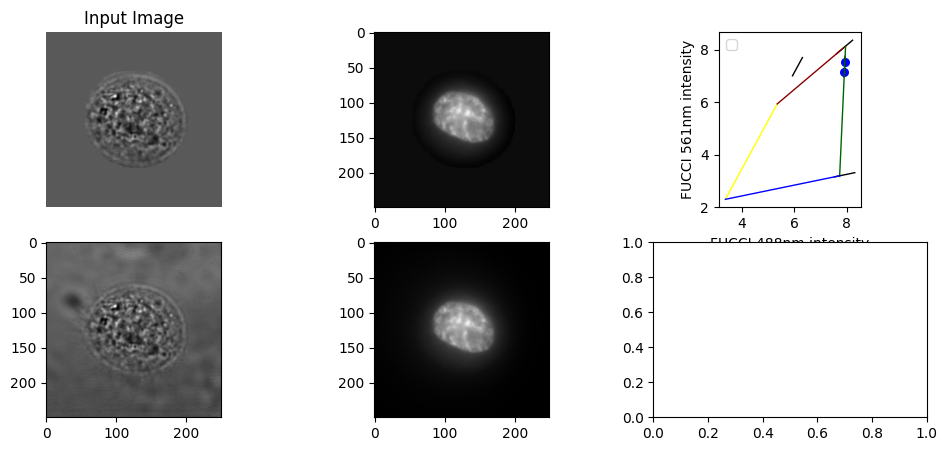

<Figure size 640x480 with 0 Axes>

Target sample: [0.0]
Prediction sample: [0.022492200136184692]
Residual (geodesic distance): 0.022492200136184692
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


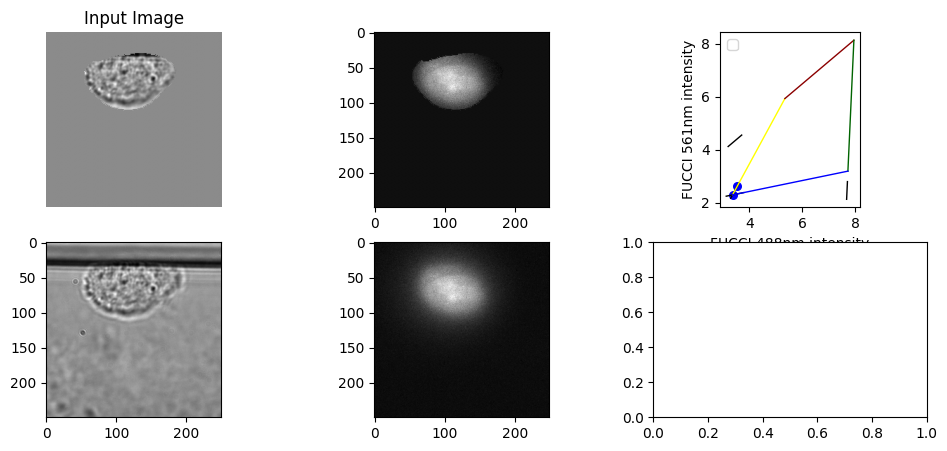

<Figure size 640x480 with 0 Axes>

Target sample: [0.3610532879829407]
Prediction sample: [0.3436935842037201]
Residual (geodesic distance): -0.01735970377922058
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


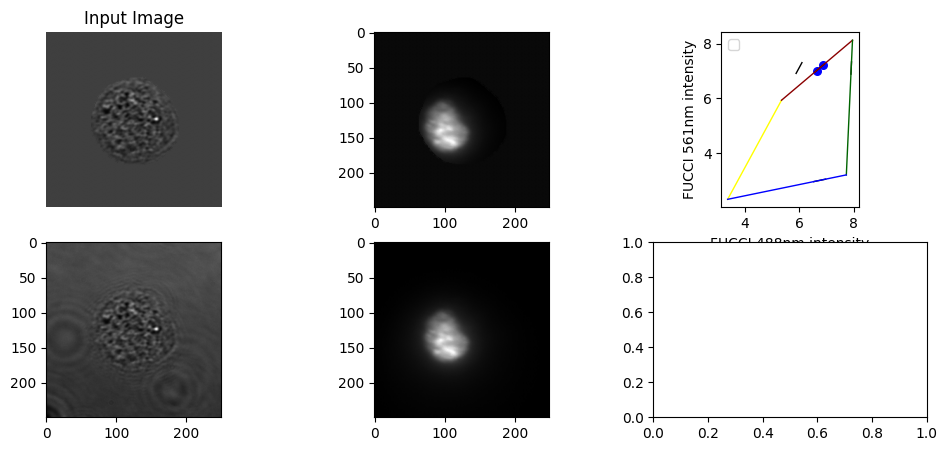

<Figure size 640x480 with 0 Axes>

Target sample: [0.20309391617774963]
Prediction sample: [0.1880960762500763]
Residual (geodesic distance): -0.01499783992767334
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


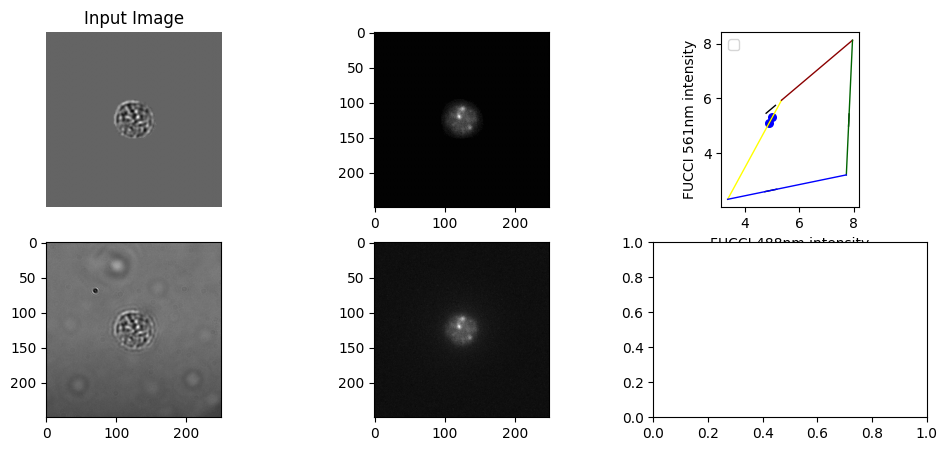

<Figure size 640x480 with 0 Axes>

Target sample: [0.2336173802614212]
Prediction sample: [0.24647943675518036]
Residual (geodesic distance): 0.012862056493759155
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


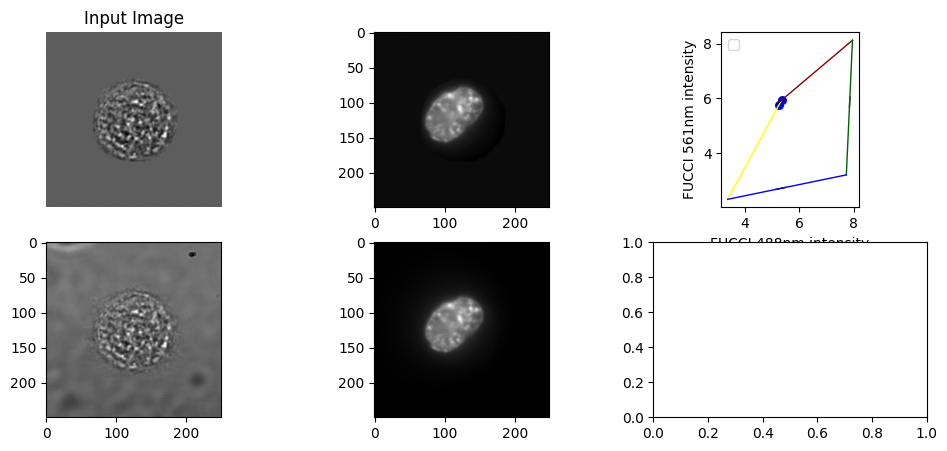

<Figure size 640x480 with 0 Axes>

Target sample: [0.0]
Prediction sample: [0.012585394084453583]
Residual (geodesic distance): 0.012585394084453583
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


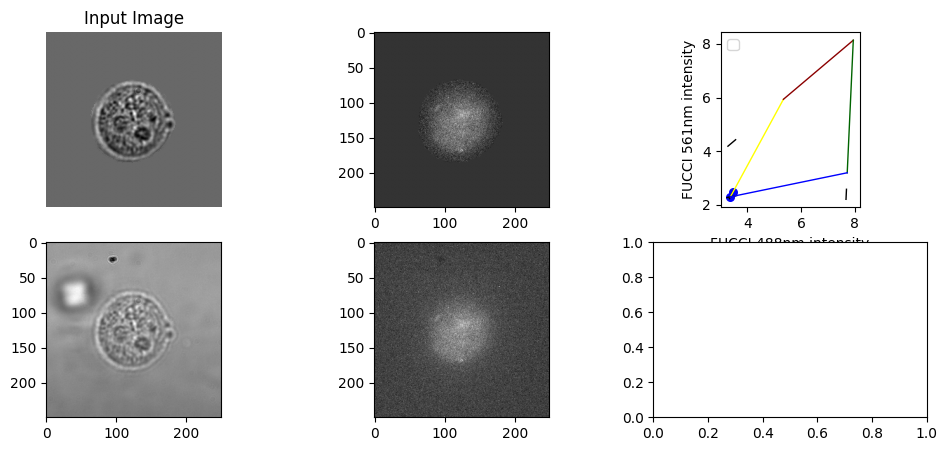

<Figure size 640x480 with 0 Axes>

Target sample: [0.2474481165409088]
Prediction sample: [0.2597896456718445]
Residual (geodesic distance): 0.012341529130935669
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


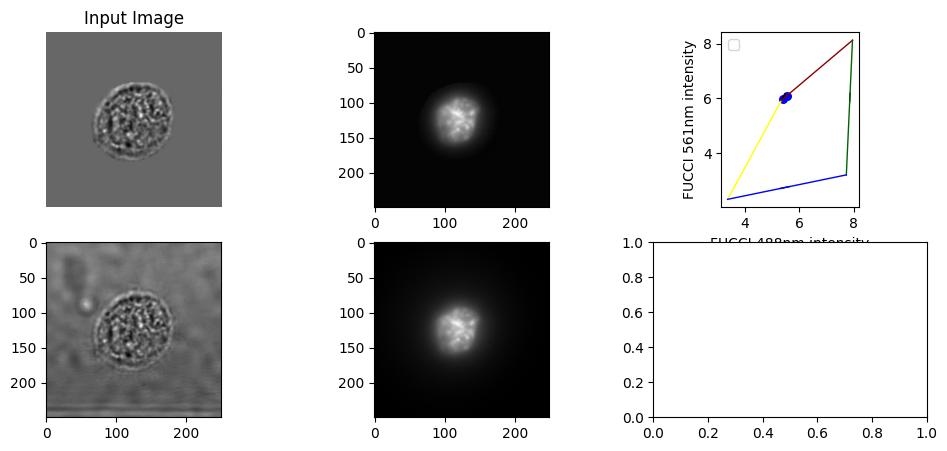

<Figure size 640x480 with 0 Axes>

Target sample: [0.18724526464939117]
Prediction sample: [0.17789077758789062]
Residual (geodesic distance): -0.00935448706150055
-----
polygon parameters:
  n1: [-0.87856398  0.47762467]
  n2: [-0.64555328  0.76371523]
  n3: [-0.9989551   0.04570243]
  n4: [-0.20160379  0.97946716]
  c1: 1.9
  c2: -1.1
  c3: 7.6
  c4: -1.6
 Cutting points:
  [3.36951432 2.30012602]
  [5.34506694 5.93404505]
  [7.94854555 8.13471369]
  [7.72260384 3.19612275]


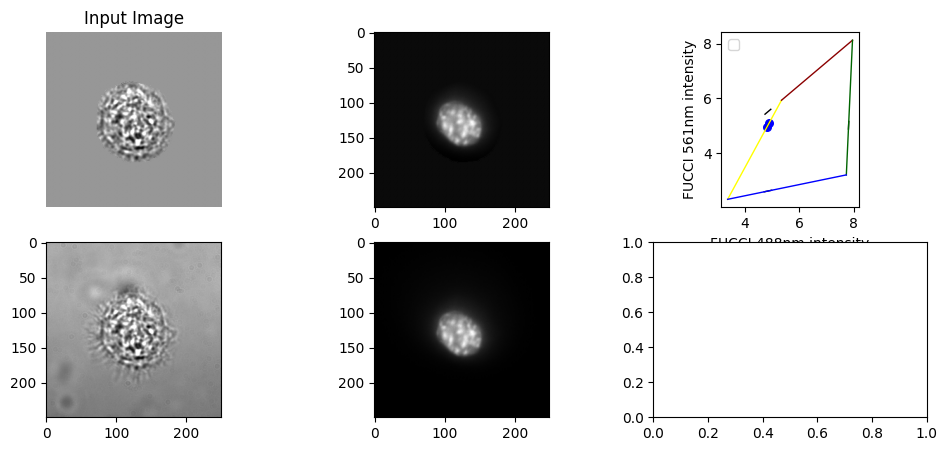

<Figure size 640x480 with 0 Axes>

In [33]:
for evaluation_tuple in evaluation_tuples[:60]:
    inputs_raw_sample, input_sample, target_sample, prediction_sample, residual_sample = evaluation_tuple
    print("Target sample:", target_sample)
    print("Prediction sample:", prediction_sample)
    print("Residual (geodesic distance):", residual_sample)
    print("-----")
    
    import matplotlib.pyplot as plt

    # Create a figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(12, 5))
    ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

    # Plot the input image (2 channels)
    input_array = np.array(input_sample)
    inputs_raw_array = np.array(inputs_raw_sample)
    # Assuming input is [2, H, W], transpose to [H, W, 2] for visualization
    
    img_display = np.transpose(input_array, (1, 2, 0))
    img_raw_display = np.transpose(inputs_raw_array, (1, 2, 0))
    # Display 2 channels separately or as a composite
    ax1.imshow(img_display[:, :, 0], cmap='gray')
    ax2.imshow(img_display[:, :, 1], cmap='gray')
    ax4.imshow(img_raw_display[:, :, 0], cmap='gray')
    ax5.imshow(img_raw_display[:, :, 1], cmap='gray')
    ax1.set_title("Input Image")
    ax1.axis('off')
    target_sample = projector.phase_to_curve(target_sample[0])
    prediction_sample = projector.phase_to_curve(prediction_sample[0])
    projector.plot(ax=ax3, intensity_points=np.asarray([target_sample, prediction_sample]), lw=1, plot_random_projections=True)
    plt.tight_layout()
    plt.show()
